<div style="background:linear-gradient(135deg,#4c0519 0%,#be123c 55%,#fb7185 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 66 · Sampling &amp; Data Collection</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Bias in Data Collection ✈️</div>
  <div style="font-size:15px;color:#fff1f2;max-width:740px;line-height:1.6">Bias is systematic error, baked in by HOW data is gathered. We quantify coverage, nonresponse, and response bias, recreate Abraham Wald&#39;s survivorship-bias airplanes, and see how biased data trains biased models.</div>
  <div style="margin-top:16px;font-size:13px;color:#fecdd3">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
ROSE="#e11d48"; DEEP="#be123c"; LIGHT="#fb7185"; INK="#1a2138"; GRID="#e6e9f2"; TEAL="#0d9488"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
rng = np.random.default_rng(66)

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 1 · COVERAGE BIAS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">When the frame misses part of the population</div>
<div style="color:#4a5578;margin-top:6px">Coverage bias strikes when your sampling FRAME (the list you draw from) does not cover the whole population. A landline-only phone frame misses younger people, so any trait tied to age is mis-estimated, before a single call is made.</div>
</div>

In [2]:
N=200_000
age = rng.integers(18, 85, N)
# support for a policy declines with age
support = rng.random(N) < (0.75 - 0.006*(age-18))
print(f"TRUE support in the population = {support.mean():.1%}")
# landline frame: older people far likelier to be listed
in_frame = rng.random(N) < (age-15)/80
frame_est = support[in_frame].mean()
print(f"landline-frame estimate        = {frame_est:.1%}  (frame mean age {age[in_frame].mean():.0f} vs {age.mean():.0f})")
print(f"coverage bias = {(frame_est-support.mean())*100:+.1f} points, because the frame skews old")

TRUE support in the population = 55.4%
landline-frame estimate        = 49.2%  (frame mean age 61 vs 51)
coverage bias = -6.2 points, because the frame skews old


The frame, not the sampling method, is the culprit. People outside the frame have zero chance of selection, so their views never enter, no matter how carefully you sample those who remain. Undercoverage is invisible in the data itself; you must reason about who is missing.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 2 · NONRESPONSE BIAS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">When who answers differs from who does not</div>
<div style="color:#4a5578;margin-top:6px">Even with a perfect frame, the people who decline to respond can differ systematically from those who answer. In an income survey, high earners often refuse, so the observed mean is pulled DOWN. Reweighting by response rate can correct a KNOWN pattern.</div>
</div>

In [3]:
income = rng.lognormal(10.7, 0.6, N)
print(f"TRUE mean income = ${income.mean():,.0f}")
# response probability falls as income rises (privacy)
resp_p = 0.8 - 0.5*(income > np.quantile(income,0.7))
responded = rng.random(N) < resp_p
naive = income[responded].mean()
print(f"observed (responders only)    = ${naive:,.0f}  (nonresponse bias {(naive/income.mean()-1)*100:+.1f}%)")
# correct with inverse-response-propensity weights
w = 1/resp_p[responded]
weighted = np.average(income[responded], weights=w)
print(f"inverse-propensity weighted    = ${weighted:,.0f}  (bias {(weighted/income.mean()-1)*100:+.1f}%)")

TRUE mean income = $53,162
observed (responders only)    = $43,734  (nonresponse bias -17.7%)
inverse-propensity weighted    = $53,172  (bias +0.0%)


Nonresponse quietly biases the result: refusers are not a random subset. When the response pattern is known, inverse-propensity weighting up-weights the under-represented and largely repairs the estimate. When it is unknown, as it usually is, the bias simply persists, which is why a high response rate matters so much.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 3 · RESPONSE &amp; MEASUREMENT BIAS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">When the answers themselves are skewed</div>
<div style="color:#4a5578;margin-top:6px">Sometimes the data-collection INSTRUMENT distorts answers: leading questions, social desirability, or faulty recall. We model a survey on weekly exercise where respondents over-report by a socially-desirable amount.</div>
</div>

In [4]:
true_hours = np.clip(rng.normal(3.0, 2.0, N), 0, None)
print(f"TRUE mean exercise = {true_hours.mean():.2f} h/week")
# social-desirability bias: people inflate, more so if they actually do little
reported = true_hours + np.clip(rng.normal(2.0, 1.0, N) - 0.3*true_hours, 0, None)
print(f"self-reported mean = {reported.mean():.2f} h/week  (response bias {reported.mean()-true_hours.mean():+.2f} h)")
print(f"a neutrally-worded, anonymous instrument shrinks this gap; the bias is in the MEASUREMENT, not the sample")

TRUE mean exercise = 3.06 h/week
self-reported mean = 4.25 h/week  (response bias +1.19 h)
a neutrally-worded, anonymous instrument shrinks this gap; the bias is in the MEASUREMENT, not the sample


No sampling fix helps here: every respondent gives a skewed answer. Response and measurement bias come from question wording, social pressure, or imperfect memory, and the cure is better instruments, neutral wording, anonymity, validated scales, not a bigger sample.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 4 · SURVIVORSHIP BIAS: WALD'S AIRPLANES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Reinforce where the bullet holes are NOT</div>
<div style="color:#4a5578;margin-top:6px">In WWII, the military wanted to armor bombers where returning planes showed the most bullet holes. Statistician Abraham Wald saw the flaw: those are the survivable hits. The planes hit elsewhere never came back. Armor where the survivors are UNSCATHED.</div>
</div>

In [5]:
planes = 5000
regions = ["engine","cockpit","fuselage","wings","tail"]
# every plane is hit roughly uniformly across regions
hits = rng.integers(0, len(regions), planes)
# a hit to the engine or cockpit is usually fatal -> plane does NOT return
fatal = {"engine":0.7, "cockpit":0.6, "fuselage":0.15, "wings":0.10, "tail":0.10}
survived = np.array([rng.random() > fatal[regions[h]] for h in hits])
all_counts = pd.Series([regions[h] for h in hits]).value_counts()
surv_counts = pd.Series([regions[h] for h in hits[survived]]).value_counts()
print("HITS ON ALL PLANES (true, unobservable):"); print(all_counts.reindex(regions).to_string())
print("\nHITS ON RETURNING PLANES (what we observe):"); print(surv_counts.reindex(regions).to_string())
print(f"\nNAIVE: armor the fuselage/wings (most holes among survivors)")
print(f"WALD:  armor the ENGINE/COCKPIT (fewest holes among survivors -> those hits were fatal)")

HITS ON ALL PLANES (true, unobservable):
engine      1036
cockpit      937
fuselage     997
wings       1033
tail         997

HITS ON RETURNING PLANES (what we observe):
engine      301
cockpit     371
fuselage    840
wings       928
tail        896

NAIVE: armor the fuselage/wings (most holes among survivors)
WALD:  armor the ENGINE/COCKPIT (fewest holes among survivors -> those hits were fatal)


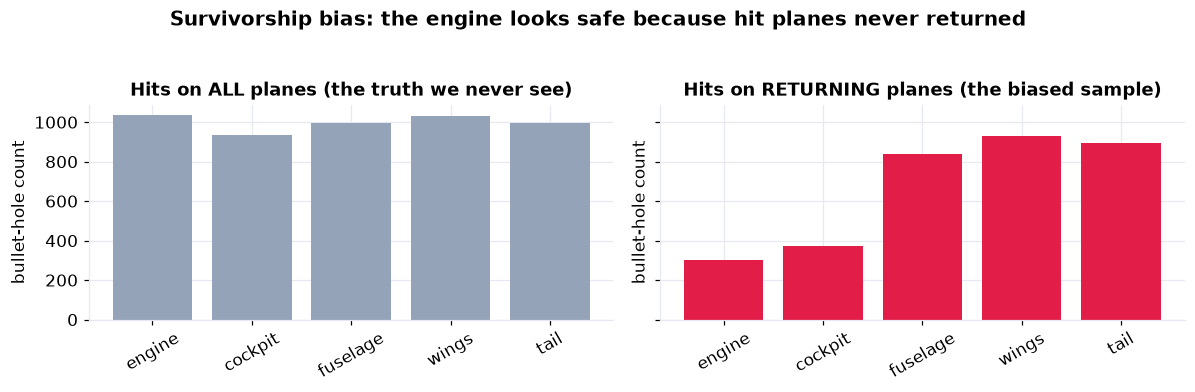

In [6]:
fig,axes=plt.subplots(1,2,figsize=(11,3.4),sharey=True)
axes[0].bar(regions, all_counts.reindex(regions).values, color="#94a3b8")
axes[0].set_title("Hits on ALL planes (the truth we never see)"); axes[0].tick_params(axis="x",rotation=30)
axes[1].bar(regions, surv_counts.reindex(regions).values, color=ROSE)
axes[1].set_title("Hits on RETURNING planes (the biased sample)"); axes[1].tick_params(axis="x",rotation=30)
for ax in axes: ax.set_ylabel("bullet-hole count")
fig.suptitle("Survivorship bias: the engine looks safe because hit planes never returned", y=1.04, fontweight="bold")
plt.tight_layout(); plt.show()

On returning planes the engine shows the FEWEST holes, not because it is rarely hit, but because engine hits were fatal and those planes are absent from the data. The sample is conditioned on survival. Wald&#39;s insight, armor the unscarred areas, is the canonical lesson that you must reason about the data you cannot see.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 5 · BIASED DATA, BIASED MODELS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The feedback loop in machine learning</div>
<div style="color:#4a5578;margin-top:6px">An AI model trained on biased historical data learns the bias and, once deployed, generates more biased data, a self-reinforcing loop. We simulate a hiring model trained on records where group B was unfairly under-hired.</div>
</div>

In [7]:
n=20000
group = rng.integers(0,2,n)               # 0 and 1, equally qualified on average
skill = rng.normal(50,10,n)               # true qualification, same for both groups
# HISTORICAL bias: group 1 was hired only at high skill (unfair past decisions)
hired_hist = ((group==0) & (skill>50)) | ((group==1) & (skill>62))
print(f"historical hire rate: group0 {hired_hist[group==0].mean():.0%}, group1 {hired_hist[group==1].mean():.0%}  (unfair gap)")
# a model trained to predict "hired" learns the biased pattern
# proxy: predict hire if skill exceeds the group-specific historical bar
thr0 = np.quantile(skill[(group==0)], 1-hired_hist[group==0].mean())
thr1 = np.quantile(skill[(group==1)], 1-hired_hist[group==1].mean())
model_hire = ((group==0)&(skill>thr0)) | ((group==1)&(skill>thr1))
print(f"model hire rate:      group0 {model_hire[group==0].mean():.0%}, group1 {model_hire[group==1].mean():.0%}  (bias reproduced)")
print("\nthe model inherits the historical bias and would feed it back as new training data")

historical hire rate: group0 50%, group1 11%  (unfair gap)
model hire rate:      group0 50%, group1 11%  (bias reproduced)

the model inherits the historical bias and would feed it back as new training data


The model is accurate at predicting the past, and that is the trap: the past was biased, so faithful learning reproduces the bias and deploys it at scale. Fixing it requires intervening on the data and objective, auditing by subgroup, debiasing labels, fairness constraints, not just more data. Bias in collection becomes bias in the model.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✈️ Bias is systematic, and design-deep</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Coverage bias omits part of the population from the frame; nonresponse bias lets refusers differ from responders; response bias skews the answers themselves; survivorship bias conditions on the cases that made it into the data. None shrink with sample size, and all trace back to HOW data was collected. In machine learning the same biases train biased models that feed the loop, which is why representative, well-measured collection is the foundation of trustworthy data and trustworthy AI. This completes Part X.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>